In [1]:
import sys
sys.path.append('../')
import imageio
import matplotlib.pyplot as plt
import json
import os
from utils.paths import path_data_cholect50
from vid_inference.scenegraph_visualizer import SceneGraphVisualizer
from data.cholec_scene_graph import CholecSceneGraphDataset
from copy import deepcopy
from IPython.display import SVG, display

In [2]:
def rename_anatomy(label):
    return \
    {        
        "abdominal_wall": "Abdom. Wall",
        "liver": "Liver",
        "gastrointestinal_tract": "GI Tract",
        "fat": "Fat",
        "grasper": "Grasper",
        "connective_tissue": "Connective Tissue",
        "blood": "Blood",
        "cystic_duct": "Cystic Duct",
        "hook": "Hook",
        "gallbladder": "Gallbladder",}[label]



sg_visualizer = SceneGraphVisualizer(list(map(rename_anatomy, list(CholecSceneGraphDataset.SEG_LABELS.keys()))))

In [12]:
idx = 12
video = imageio.get_reader(f"/local/scratch/Cholec80/cholec80_full_set/videos/video{idx:02d}.mp4")
scene_graph_video = imageio.get_reader(f"/local/scratch/clmn1/videoNCA/inference/Cholec/{idx:02d}/output.mp4")
scene_graphs = json.load(open(os.path.join(path_data_cholect50, "labels", f"VID{idx:02d}.json")))
prediction = json.load(open(f"/local/scratch/clmn1/videoNCA/inference/Cholec/{idx:02d}/predictions.json"))
FPS = video.get_meta_data()["fps"]

In [4]:
_min = 10
sec = 23
offset = -25

In [5]:
_min = 13
sec = 34
offset = -25

In [6]:
_min = 20
sec = 16
offset = -25

grasper,grasp,peritoneum
grasper,retract,gallbladder


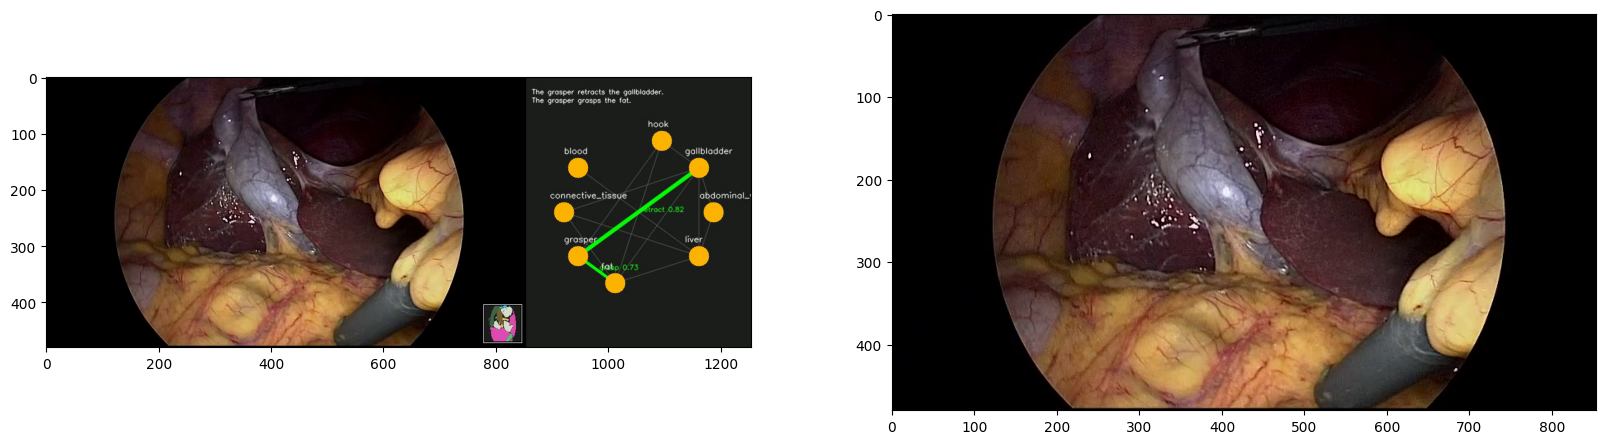

In [15]:
_min = 2
sec = 24
offset = -25
idx = int(FPS * 60 * _min + FPS * sec +offset)
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(scene_graph_video.get_data(idx - 25))
plt.subplot(1, 2, 2)
plt.imshow(video.get_data(idx))
for relation in scene_graphs['annotations'][str(idx // 25)]:
    print(scene_graphs['categories']['triplet'][str(relation[0])])
plt.savefig(f"qualitative/cholec_{idx}.pdf")

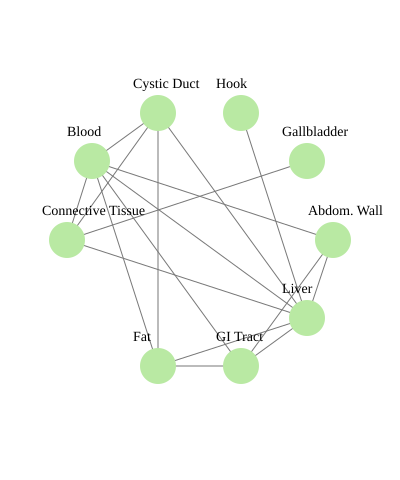

In [8]:
vis_this_pred = deepcopy(prediction[str(idx)])
vis_this_pred["semantic_relations"] = [[rename_anatomy(rel[0]), rel[1], rename_anatomy(rel[2]), rel[3]] for rel in vis_this_pred["semantic_relations"]]
vis_this_pred["geometric_relations"] = [[rename_anatomy(rel[0]), rename_anatomy(rel[1])] for rel in vis_this_pred["geometric_relations"]]
svg_str = sg_visualizer.render_graph_svg(vis_this_pred["semantic_relations"], vis_this_pred["geometric_relations"])
display(SVG(svg_str))

In [9]:
with open(f"qualitative/cholec_{idx}_pred.svg", "w") as f:
    f.write(svg_str)